<a href="https://colab.research.google.com/github/amkathum/-Colab/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# By Mohamed Eltayeb

## Task: Predict number of bikers on a given day using linear regression

You are provided with a dataset about Seattle's Fremont Bridge in the form of a csv file.
The data contains different details about a given day, like weather, temperature and other factors (see the dataframe preview below) for more details. The data also contains how many bikers were observed crossing the bridge that day.

You are provided with the code to download and load the csv file.

Your task is to **train a linear regression model** which takes in the parameters of the day (you can drop the columns that you think you don't need) and predicts the number of bikers according to those parameters.

**Divide the data** into a train (80%) and a validation data set (20%).

**Print train and validation losses**.

You are **not allowed** to use LinearRegression from sklearn.linear_model.

## Import libraries

In [1]:
from IPython.display import clear_output

In [2]:
# Incase you run this notebook outside colab (where the libraries aren't already pre-installed)

%pip install gdown
%pip install pandas
%pip install numpy

clear_output()

In [3]:
import pandas as pd
import numpy as np

## Load the Data

In [31]:
# Download the CSV file.
!gdown 1_eJU8Y-31_l0oq1sSJT6pROJyo-ufuvD

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1_eJU8Y-31_l0oq1sSJT6pROJyo-ufuvD

but Gdown can't. Please check connections and permissions.


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
data_df = pd.read_csv('/bikers_data.csv')
data_df

,Date,Number of bikers,Mon,Tue,Wed,Thu,Fri,Sat,Sun,holiday,daylight_hrs,Rainfall (in),Temp (F),dry day
0,10/3/2012,14084,0,0,1,0,0,0,0,0,11.277359,0.00,56.0,1
1,10/4/2012,13900,0,0,0,1,0,0,0,0,11.219142,0.00,56.5,1
2,10/5/2012,12592,0,0,0,0,1,0,0,0,11.161038,0.00,59.5,1
3,10/6/2012,8024,0,0,0,0,0,1,0,0,11.103056,0.00,60.5,1
4,10/7/2012,8568,0,0,0,0,0,0,1,0,11.045208,0.00,60.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,12/27/2019,4552,0,0,0,0,1,0,0,0,8.237706,0.01,41.0,0
2642,12/28/2019,3352,0,0,0,0,0,1,0,0,8.245532,0.00,44.0,1
2643,12/29/2019,3692,0,0,0,0,0,0,1,0,8.254701,0.01,45.5,0
2644,12/30/2019,7212,1,0,0,0,0,0,0,0,8.265207,0.04,45.5,0


## Let's do some EDA

### Let's look firstly into the target.

<Axes: >

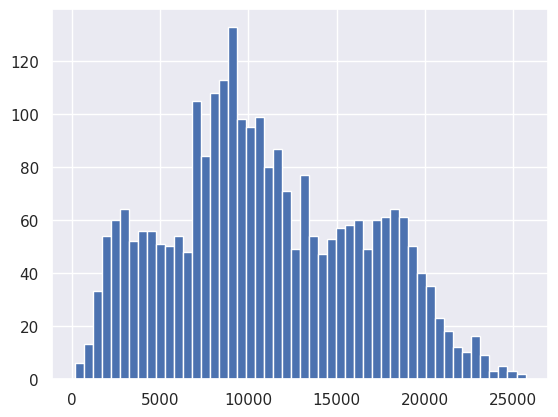

In [47]:
#Target Histogram
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()
data_df['Number of bikers'].hist(bins=50)

In [48]:
print('Min: ',data_df['Number of bikers'].min())
print('Max: ',data_df['Number of bikers'].max())
print('Standard Deviation: ',data_df['Number of bikers'].std())
print('Kurtosis',data_df['Number of bikers'].kurtosis())

Min:  152
Max:  25712
Standard Deviation:  5479.6412913844115
Kurtosis -0.7557532071975133


##### It follows a normal distribution and there is No outliers.

### What about the histograms of the other features? Let's have a look.

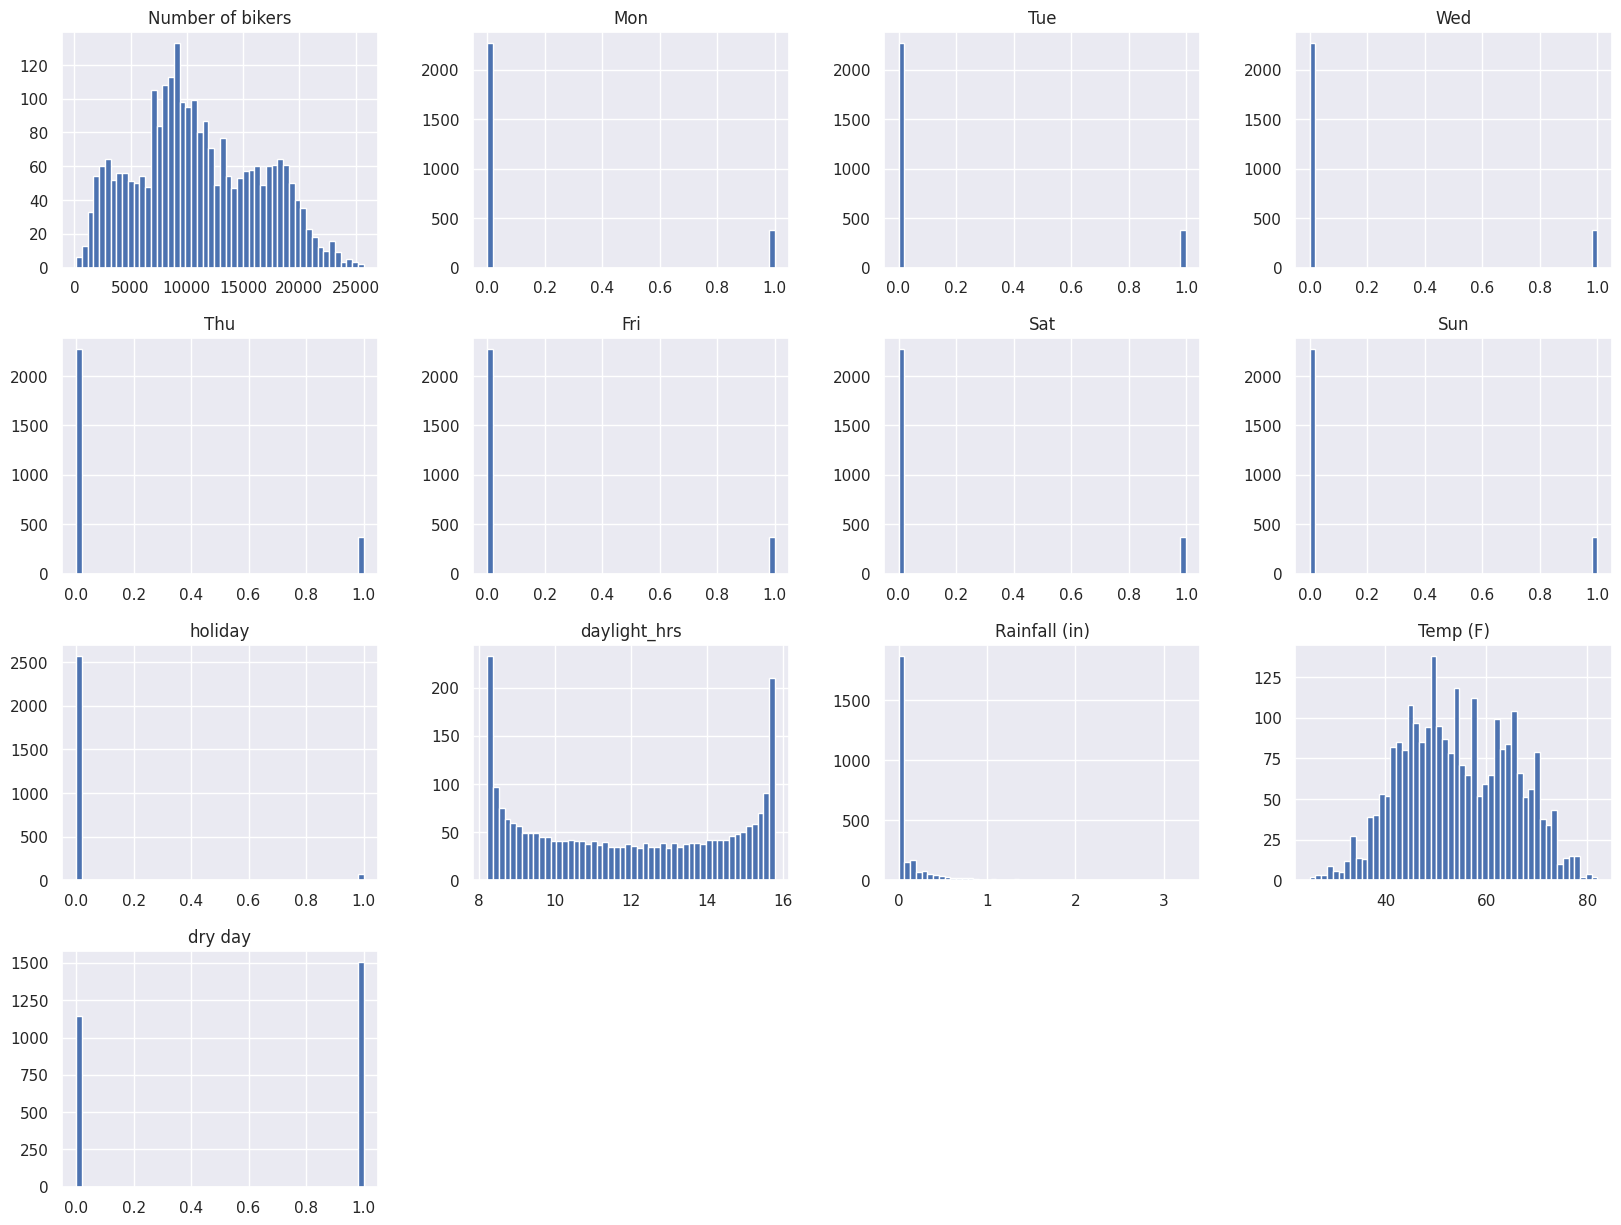

In [49]:
#Numerical Features Histograms (Train)
num_feats = list(data_df.select_dtypes(include=['int64', 'float64', 'int32']).columns)
data_df[num_feats].hist(figsize=(20,15),bins=50);

##### Appearntly, no need for log-transformation. The distributions looks good enough to work with the linear regression.

### But what about the correlation?

In [50]:
def plot_correlation_matrix(X, y):
    full_data = pd.DataFrame(X)
    full_data['target'] = y
    corr_matrix = full_data.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title('Full Correlation Matrix')
    plt.show()
plt.figure(figsize=(15,15))
plot_correlation_matrix(data_df.drop('Number of bikers',axis=1), data_df['Number of bikers'])

ValueError: could not convert string to float: '10/3/2012'

<Figure size 1500x1500 with 0 Axes>

##### Doesn't sound really bad. Maybe some correlation between the temperature and daylight hours. Maybe try to manipulate these later, but for now it seems we are good to go with no big multicollinearity problem.

### Let's investigate the features a bit more.

In [ ]:
data_df.info()

##### The data contains 12 features and a target (Number of bikers).
##### We can see that no missing values there.
##### Btw, we may need to extract the features from the date feature to make the model utilize it better.

In [ ]:
data_df.head()

##### To help the linear regression converge better, we may need to scale our data.

### Let's check the date ranges.

In [ ]:
data_df.describe()

### What about the date?

In [ ]:
print(f"first day: {data_df['Date'].min()}")
print(f"last day: {data_df['Date'].max()}")

### Well, this sound like a time series problem!
### Based on the "Date" feature given, let's formulate the task to predict the number of bikers in future dates.
### To validate our model properly to make it forecasts future number of bikers, we will divide the data using a time-base split, so that the training data is older than validation data which is older than test data. Specifically, a time-series split.

#### For now, let's try to build our model with scaling and some feature engineering. We will extract the Date features as well.
#### Firstly we will sort the data based on time. Then take the last 1 year (2019) as a test set. Then we will make our k-fold time series split using the left data. We will use linear regression written from scratch for modeling. and use time series split from sklearn to make the folds.

In [ ]:
# Convert date feature from object to time
data_df['Date'] = data_df['Date'].astype('datetime64[ns]')
data_df = data_df.sort_values('Date').reset_index(drop=True)

In [ ]:
# Split to train and test
train_df = data_df[data_df['Date'] < '2019-01-01'].reset_index(drop=True)
test_df = data_df[(data_df['Date'] >= '2019-01-21')].reset_index(drop=True)

In [ ]:
print(f"Current training data shape: {train_df.shape}")
print(f"Current testing data shape: {test_df.shape}")

### Let's start building our model.

### Feature engineering
##### Let's extract the date features (Day, Month,...etc), and calculate some interaction features.

In [ ]:
for dataset in [train_df,test_df]:
    dataset['Day'] = dataset.Date.dt.day
    dataset['Month'] = dataset.Date.dt.month
    dataset['Year'] = dataset.Date.dt.year
    dataset['DayOfWeek'] = dataset.Date.dt.dayofweek
    dataset['WeekOfYear'] = dataset.Date.dt.weekofyear
    dataset['Quarter'] = dataset.Date.dt.quarter
    dataset.drop('Date',axis=1, inplace=True)

In [ ]:
# Interaction features
for dataset in [train_df,test_df]:
    dataset['Rain per hour'] = dataset['daylight_hrs'] / (dataset['Rainfall (in)']+1)

### Let's scale the data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
feats = train_df.columns.drop('Number of bikers')
le = MinMaxScaler()
df = pd.concat([train_df, test_df])
for f in feats:
    le.fit(df[f].values.reshape(-1,1))
    train_df[f] = le.transform(train_df[f].values.reshape(-1,1))
    test_df[f] = le.transform(test_df[f].values.reshape(-1,1))

### Modeling

### We will use Ridge.

In [ ]:
y = train_df['Number of bikers'] # target
X = train_df.drop(['Number of bikers'], axis=1) # input features

In [ ]:
# The model
class Ridge():
    def __init__(self, _lambda = 0.1):
        self.weights = None
        self._lambda = _lambda

    def fit(self, X, y):
        self.weights = np.linalg.inv(X.T @ X + self._lambda*np.eye(X.shape[1])) @ X.T @ y

    def predict(self,X):
        return X @ self.weights

    def print_weights(self):
        print("Weights:", self.weights)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
print('Validating...')
lr = Ridge(_lambda = 0.1)

# Out-of-fold predictions
oof_pred = pd.Series(0,index=train_df.index)

scores = []
for i, (train_index, test_index) in enumerate(TimeSeriesSplit().split(X, y)):

    print("Train period:", data_df.loc[train_index,'Date'].min(), "to", data_df.loc[train_index,'Date'].max())
    print("Validation period:", data_df.loc[test_index,'Date'].min(), "to", data_df.loc[test_index,'Date'].max())

    X_Train, X_Test = X.loc[train_index,:], X.loc[test_index,:]
    y_Train, y_Test = y[train_index], y[test_index]
    lr.fit(X_Train.values,y_Train.values)
    y_pred = lr.predict(X_Test.values)
    oof_pred[test_index] = y_pred
    scores.append(np.sqrt(mean_squared_error(y_Test.values,y_pred)))
    print(f"RMSE for {i+1}th fold: {scores[-1]}\n")

print("\nMean of folds:",np.mean(scores),"\nSTD of folds:", np.std(scores))

### Let's plot the predictions histogram against the training target.

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
axes.hist(y, bins=50, color='blue', alpha=0.7, label='True Values')
axes.hist(oof_pred, bins=50, color='red', alpha=0.7, label='Predictions')
axes.set_title(f'Histogram for Number of Bikers')
axes.set_xlabel('Value')
axes.set_ylabel('Frequency')
axes.legend()

The zeros looks due to the first days predictions not included in the validating. This is natural becuase we have to start training from some data. So starting from the 2012 to predict the next years, we cannot make predictions for 2012. But the distribution of the other samples looks intersting!

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
axes.hist(y[380:], bins=50, color='blue', alpha=0.7, label='True Values')
axes.hist(oof_pred[380:], bins=50, color='red', alpha=0.7, label='Predictions')
axes.set_title(f'Histogram for Number of Bikers')
axes.set_xlabel('Value')
axes.set_ylabel('Frequency')
axes.legend()

### What about test set performance?

In [ ]:
lr.fit(X,y)
y_pred = lr.predict(test_df.drop('Number of bikers',axis=1).values)
print(f'Test Set RMSE: ', np.sqrt(mean_squared_error(test_df['Number of bikers'].values,y_pred)))

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
axes.hist(test_df['Number of bikers'], bins=50, color='blue', alpha=0.7, label='True Values')
axes.hist(y_pred, bins=50, color='red', alpha=0.7, label='Predictions')
axes.set_title(f'Histogram for Number of Bikers')
axes.set_xlabel('Value')
axes.set_ylabel('Frequency')
axes.legend()

### Let's check the features importance. We will look into the magnitude of each feature. That correspondence to its importance in predicting the target.

In [ ]:
imps = pd.DataFrame(X.columns,columns=['Feature Name'])
imps['Importance'] = np.abs(lr.weights)
imps.sort_values(by='Importance',ascending=False)

In [ ]:
from sklearn.metrics import confusion_matrix

def plots(y_test, y_pred):
    # Scatter Plot of Predictions vs Real Values
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Scatter Plot of Predictions vs Real Values (Correlation: {cr:0.2f})')
    plt.show()

cr = x=np.corrcoef(test_df['Number of bikers'].values,y_pred)[0,1]
plots(test_df['Number of bikers'].values,y_pred)